In [ ]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
%cd "C:/Users/mateo/Desktop/polymath-jr-drifting"
# This notebook uses DriftXpress; exact drift uses its separate loss/cache API in src.drift.
from src.driftXpress import *
from src.eval import *
from src.training import (
    compose_objective,
    format_epoch_losses,
    gradient_report,
    per_loss_gradient_norms,
    set_requires_grad,
)
torch.manual_seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


In [2]:
transform = transforms.ToTensor()

SELECTED_DIGITS = (0, 8, 2, 4, 7, 9)
DIGIT_TO_CLASS = {digit: index for index, digit in enumerate(SELECTED_DIGITS)}
CLASS_TO_DIGIT = np.asarray(SELECTED_DIGITS)

train_data = datasets.MNIST("data", train=True, download=True, transform=transform)
test_data = datasets.MNIST("data", train=False, download=True, transform=transform)

def keep_selected_digits(dataset):
    selected = torch.tensor(SELECTED_DIGITS, dtype=dataset.targets.dtype)
    mask = torch.isin(dataset.targets, selected)
    dataset.data = dataset.data[mask]
    raw_targets = dataset.targets[mask]
    dataset.targets = torch.tensor(
        [DIGIT_TO_CLASS[int(digit)] for digit in raw_targets],
        dtype=torch.long,
    )
    return dataset

train_data = keep_selected_digits(train_data)
test_data = keep_selected_digits(test_data)

BATCH_SIZE = 500
train_loader = DataLoader(
    train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Selected digits:", SELECTED_DIGITS)
print("Train samples:", len(train_data))
print("Test samples:", len(test_data))


Selected digits: (0, 8, 2, 4, 7, 9)
Train samples: 35788
Test samples: 6005


In [3]:
class f(nn.Module):
    def __init__(self, input_dim=784, latent_dim=64, num_classes=6, label_dim=16):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.label_dim = label_dim

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 192), nn.LeakyReLU(0.2),
            nn.Linear(192, 96), nn.LeakyReLU(0.2),
        )
        self.fc_mu = nn.Linear(96, latent_dim)
        self.fc_var = nn.Linear(96, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 96), nn.LeakyReLU(0.2),
            nn.Linear(96, 192), nn.LeakyReLU(0.2),
            nn.Linear(192, input_dim), nn.Sigmoid(),
        )

        self.label_embedding = nn.Embedding(num_classes, label_dim)
        self.generator = nn.Sequential(
            nn.Linear(latent_dim + label_dim, 48), nn.SiLU(),
            nn.Linear(48, 48), nn.SiLU(),
            nn.Linear(48, 48), nn.SiLU(),
            nn.Linear(48, latent_dim),
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def get_latent(self, y):
        features = self.encoder(y)
        mu = self.fc_mu(features)
        logvar = self.fc_var(features)
        latent = self.reparameterize(mu, logvar)
        return mu, logvar, latent

    def decode(self, z):
        return self.decoder(z)

    def generate(self, noise, labels):
        label_features = self.label_embedding(labels.long())
        generator_input = torch.cat([noise, label_features], dim=1)
        generated_latent = self.generator(generator_input)
        generated_final = self.decode(generated_latent)
        return generated_latent, generated_final


class LatentDiscriminator(nn.Module):
    """Class-conditional discriminator for raw generated latents."""
    def __init__(self, latent_dim=64, num_classes=6, label_dim=16):
        super().__init__()
        self.label_embedding = nn.Embedding(num_classes, label_dim)
        self.network = nn.Sequential(
            nn.Linear(latent_dim + label_dim, 64), nn.LeakyReLU(0.2),
            nn.Linear(64, 64), nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
        )

    def forward(self, latents, labels):
        label_features = self.label_embedding(labels.long())
        discriminator_input = torch.cat([latents, label_features], dim=1)
        return self.network(discriminator_input).squeeze(-1)


In [16]:
model = f()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")

Total parameters: 369664
Trainable parameters: 369664


In [4]:
def build_conditional_drift_cache(model, data_loader, num_classes, num_landmarks, T):
    """Build one fixed-reference attraction cache for each digit."""
    model.eval()
    reference_latents = {digit: [] for digit in range(num_classes)}

    with torch.no_grad():
        for images, labels in data_loader:
            y_pos = images.to(device, non_blocking=True).flatten(start_dim=1)
            _, _, y_pos_latent = model.get_latent(y_pos)
            labels = labels.to(device, non_blocking=True)
            for digit in range(num_classes):
                mask = labels == digit
                if mask.any():
                    reference_latents[digit].append(y_pos_latent[mask].detach())

    drift_cache = {}
    for digit in range(num_classes):
        if not reference_latents[digit]:
            raise ValueError(f"No reference samples found for digit {digit}.")
        support = torch.cat(reference_latents[digit], dim=0)
        landmarks = select_landmarks(support, num_landmarks)
        K_uu_inv_sqrt = build_nystrom_cache(landmarks, T)
        Ap, bp = pre_compute_summaries(support, landmarks, K_uu_inv_sqrt, T)
        drift_cache[digit] = (landmarks, K_uu_inv_sqrt, Ap, bp)

    return drift_cache


def conditional_drift_loss(generated, labels, drift_cache, T):
    batch_size = generated.shape[0]
    total_loss = generated.new_zeros(())
    field = torch.zeros_like(generated)

    for digit_tensor in torch.unique(labels):
        digit = int(digit_tensor.item())
        mask = labels == digit
        landmarks, K_uu_inv_sqrt, Ap, bp = drift_cache[digit]
        digit_loss, digit_field = drift_loss(
            generated[mask], landmarks, K_uu_inv_sqrt, Ap, bp, T
        )
        weight = mask.float().sum() / batch_size
        total_loss = total_loss + weight * digit_loss
        field[mask] = digit_field

    return total_loss, field


def set_requires_grad(module, requires_grad):
    for parameter in module.parameters():
        parameter.requires_grad_(requires_grad)


In [ ]:
def training_loop(
    num_epochs, T, num_landmarks,
    lambda_kl, lambda_drift, lambda_var, lambda_cov, lambda_adv,
    lambda_representation=1.0, loss_scale=1.0,
    batch_size=1000, lr=1e-3, disc_lr=1e-3,
):
    model = f(input_dim=784, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES).to(device)
    discriminator = LatentDiscriminator(
        latent_dim=LATENT_DIM, num_classes=NUM_CLASSES
    ).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    discriminator_optimizer = optim.AdamW(discriminator.parameters(), lr=disc_lr)
    bce = nn.BCEWithLogitsLoss()

    train_losses, recon_losses, kl_losses = [], [], []
    drift_losses, var_losses, covar_losses = [], [], []
    adversarial_losses, discriminator_losses = [], []
    average_V, evolution = [], []
    snapshot_epochs = set(range(0, num_epochs + 1, max(1, num_epochs // 5)))
    snapshot_epochs.add(num_epochs)

    print("Conditional training with latent discriminator started")
    start_time = time.perf_counter()
    cache_start = time.perf_counter()
    print("Building fixed conditional attraction caches...")
    drift_cache = build_conditional_drift_cache(
        model, train_loader, NUM_CLASSES, num_landmarks, T
    )
    print(f"Fixed attraction caches built in {(time.perf_counter() - cache_start) / 60:.2f} minutes")

    for epoch in range(num_epochs + 1):
        model.train()
        discriminator.train()
        epoch_items = {
            key: 0.0
            for key in (
                "total", "recon", "kl", "drift", "var",
                "covar", "adv", "disc", "V"
            )
        }
        last_pos, last_neg = None, None

        for images, labels in train_loader:
            y_pos = images.to(device, non_blocking=True).flatten(start_dim=1)
            labels = labels.to(device, non_blocking=True)
            noise = torch.randn(y_pos.shape[0], LATENT_DIM, device=device)

            # Discriminator step: both latent sources are detached.
            with torch.no_grad():
                _, _, real_latent_for_disc = model.get_latent(y_pos)
                fake_latent_for_disc, _ = model.generate(noise, labels)
            real_logits = discriminator(real_latent_for_disc.detach(), labels)
            fake_logits = discriminator(fake_latent_for_disc.detach(), labels)
            real_targets = torch.ones_like(real_logits)
            fake_targets = torch.zeros_like(fake_logits)
            L_disc = 0.5 * (
                bce(real_logits, real_targets)
                + bce(fake_logits, fake_targets)
            )
            discriminator_optimizer.zero_grad(set_to_none=True)
            L_disc.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=5.0)
            discriminator_optimizer.step()

            # Algorithm 1 model step: the discriminator sees raw generated latents.
            mu, logvar, y_pos_latent = model.get_latent(y_pos)
            y_pos_recon = model.decode(y_pos_latent)
            y_neg_latent, y_neg_recon = model.generate(noise, labels)

            L_drift, V = conditional_drift_loss(
                y_neg_latent, labels, drift_cache, T
            )
            L_recon = recon_loss(y_pos_recon, y_pos)
            L_kl = kl_loss(mu, logvar)
            L_var = variance_loss(y_pos_latent) + variance_loss(y_neg_latent)
            L_cov = covariance_loss(y_pos_latent) + covariance_loss(y_neg_latent)

            # Freeze discriminator parameters for the generator adversarial step.
            set_requires_grad(discriminator, False)
            generator_logits = discriminator(y_neg_latent, labels)
            L_adv = bce(generator_logits, torch.ones_like(generator_logits))
            set_requires_grad(discriminator, True)

            loss, _ = compose_objective(
                {
                    "recon": L_recon,
                    "kl": L_kl,
                    "drift": L_drift,
                    "var": L_var,
                    "covar": L_cov,
                    "adv": L_adv,
                },
                {
                    "kl": lambda_kl,
                    "drift": lambda_drift,
                    "var": lambda_var,
                    "covar": lambda_cov,
                    "adv": lambda_adv,
                },
                lambda_representation=lambda_representation,
                loss_scale=loss_scale,
            )

            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f"Non-finite model loss at epoch {epoch}: {loss.item()}"
                )
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            epoch_items["total"] += loss.item()
            epoch_items["recon"] += L_recon.item()
            epoch_items["kl"] += L_kl.item()
            epoch_items["drift"] += L_drift.item()
            epoch_items["var"] += L_var.item()
            epoch_items["covar"] += L_cov.item()
            epoch_items["adv"] += L_adv.item()
            epoch_items["disc"] += L_disc.item()
            epoch_items["V"] += V.norm(dim=1).mean().item()
            last_pos, last_neg = y_pos_latent.detach(), y_neg_latent.detach()

        num_batches = len(train_loader)
        for key in epoch_items:
            epoch_items[key] /= num_batches

        train_losses.append(epoch_items["total"])
        recon_losses.append(epoch_items["recon"])
        kl_losses.append(epoch_items["kl"])
        drift_losses.append(epoch_items["drift"])
        var_losses.append(epoch_items["var"])
        covar_losses.append(epoch_items["covar"])
        adversarial_losses.append(epoch_items["adv"])
        discriminator_losses.append(epoch_items["disc"])
        average_V.append(epoch_items["V"])

        if epoch in snapshot_epochs:
            evolution.append({
                "epoch": epoch,
                "pos": last_pos.cpu().numpy(),
                "neg": last_neg.cpu().numpy(),
            })

        if epoch < 20 or epoch % 10 == 0 or epoch == num_epochs:
            print(f"-------- Epoch {epoch} --------")
            print(f"total={epoch_items['total']:.6f}")
            print(f"recon={epoch_items['recon']:.6f}    scaled={loss_scale * lambda_representation * epoch_items['recon']:.6f}")
            print(f"kl={epoch_items['kl']:.6f}    scaled={loss_scale * lambda_representation * lambda_kl * epoch_items['kl']:.6f}")
            print(f"drift={epoch_items['drift']:.6f}    scaled={loss_scale * lambda_drift * epoch_items['drift']:.6f}")
            print(f"var={epoch_items['var']:.6f}    scaled={loss_scale * lambda_representation * lambda_var * epoch_items['var']:.6f}")
            print(f"covar={epoch_items['covar']:.6f}    scaled={loss_scale * lambda_representation * lambda_cov * epoch_items['covar']:.6f}")
            print(f"adv={epoch_items['adv']:.6f}    scaled={loss_scale * lambda_adv * epoch_items['adv']:.6f}")
            print(f"disc={epoch_items['disc']:.6f}")
            print(f"average |V|={epoch_items['V']:.6f}")
            print(f"latent std positive={last_pos.std(dim=0).mean().item():.6f}")
            print(f"latent std negative={last_neg.std(dim=0).mean().item():.6f}")

    elapsed = (time.perf_counter() - start_time) / 60
    print(f"Finished. Training took {elapsed:.2f} minutes")
    return (
        model, discriminator, train_losses, recon_losses, kl_losses,
        drift_losses, var_losses, covar_losses, adversarial_losses,
        discriminator_losses, average_V, evolution,
    )


In [ ]:
NUM_CLASSES = 6
LATENT_DIM = 32
NUM_EPOCHS = 100
NUM_LANDMARKS = 200
TEMPERATURE = 2
LAMBDA_KL = 1e-5
LAMBDA_DRIFT = 30.0
LAMBDA_VAR = 0.1
LAMBDA_COV = 0.3
LAMBDA_REPRESENTATION = 1.0
LOSS_SCALE = 1.0  # Global multiplier; leave at 1 unless intentionally testing it.
LAMBDA_ADV = 1.0

(
    f_trained, discriminator, losses, recon_losses, kl_losses,
    drift_losses, var_losses, covar_losses, adversarial_losses,
    discriminator_losses, average_V, evolution,
) = training_loop(
    NUM_EPOCHS, TEMPERATURE, NUM_LANDMARKS,
    LAMBDA_KL, LAMBDA_DRIFT, LAMBDA_VAR, LAMBDA_COV, LAMBDA_ADV,
    lambda_representation=LAMBDA_REPRESENTATION,
    loss_scale=LOSS_SCALE,
    batch_size=BATCH_SIZE, lr=1e-3, disc_lr=1e-3,
)


In [7]:
f_trained.train()
images, labels = next(iter(train_loader))
y_pos = images.to(device).flatten(start_dim=1)
labels = labels.to(device)
noise = torch.randn(y_pos.shape[0], f_trained.latent_dim, device=device)

mu, logvar, y_pos_latent = f_trained.get_latent(y_pos)
y_neg_latent, y_neg_recon = f_trained.generate(noise, labels)
drift_cache = build_conditional_drift_cache(
    f_trained, train_loader, NUM_CLASSES, NUM_LANDMARKS, TEMPERATURE
)
L_drift, V = conditional_drift_loss(
    y_neg_latent, labels, drift_cache, TEMPERATURE
)
set_requires_grad(discriminator, False)
L_adv = F.binary_cross_entropy_with_logits(
    discriminator(y_neg_latent, labels),
    torch.ones(y_neg_latent.shape[0], device=device),
)
set_requires_grad(discriminator, True)
print("Drift gradient flow:", gradient_report(L_drift, f_trained))
print("Adversarial gradient flow:", gradient_report(L_adv, f_trained))


Drift gradient flow: {'encoder': {'total_norm': 0.0, 'nonzero_parameters': 0, 'parameter_count': 8}, 'decoder': {'total_norm': 0.0, 'nonzero_parameters': 0, 'parameter_count': 6}, 'generator': {'total_norm': 0.6624934431165457, 'nonzero_parameters': 8, 'parameter_count': 8}, 'other': {'total_norm': 0.00696035148575902, 'nonzero_parameters': 1, 'parameter_count': 1}}
Adversarial gradient flow: {'encoder': {'total_norm': 0.0, 'nonzero_parameters': 0, 'parameter_count': 8}, 'decoder': {'total_norm': 0.0, 'nonzero_parameters': 0, 'parameter_count': 6}, 'generator': {'total_norm': 11.183788478374481, 'nonzero_parameters': 8, 'parameter_count': 8}, 'other': {'total_norm': 0.2421584129333496, 'nonzero_parameters': 1, 'parameter_count': 1}}


In [8]:
def temp_search(y_pos, T_values, sample_size=500):
    idx = torch.randperm(len(y_pos))[:sample_size]
    sample = y_pos[idx]
    dists = torch.cdist(sample, sample)
    dists = dists[dists > 0]
    for T in T_values:
        logits = -dists / T
        print(f"T={T:.3f}  logits.std={logits.std().item():.3f}")

temp_search(y_pos_latent, T_values=[0.1, 0.5, 1, 2, 5, 10, 20])


T=0.100  logits.std=16.676
T=0.500  logits.std=3.335
T=1.000  logits.std=1.668
T=2.000  logits.std=0.834
T=5.000  logits.std=0.334
T=10.000  logits.std=0.167
T=20.000  logits.std=0.083


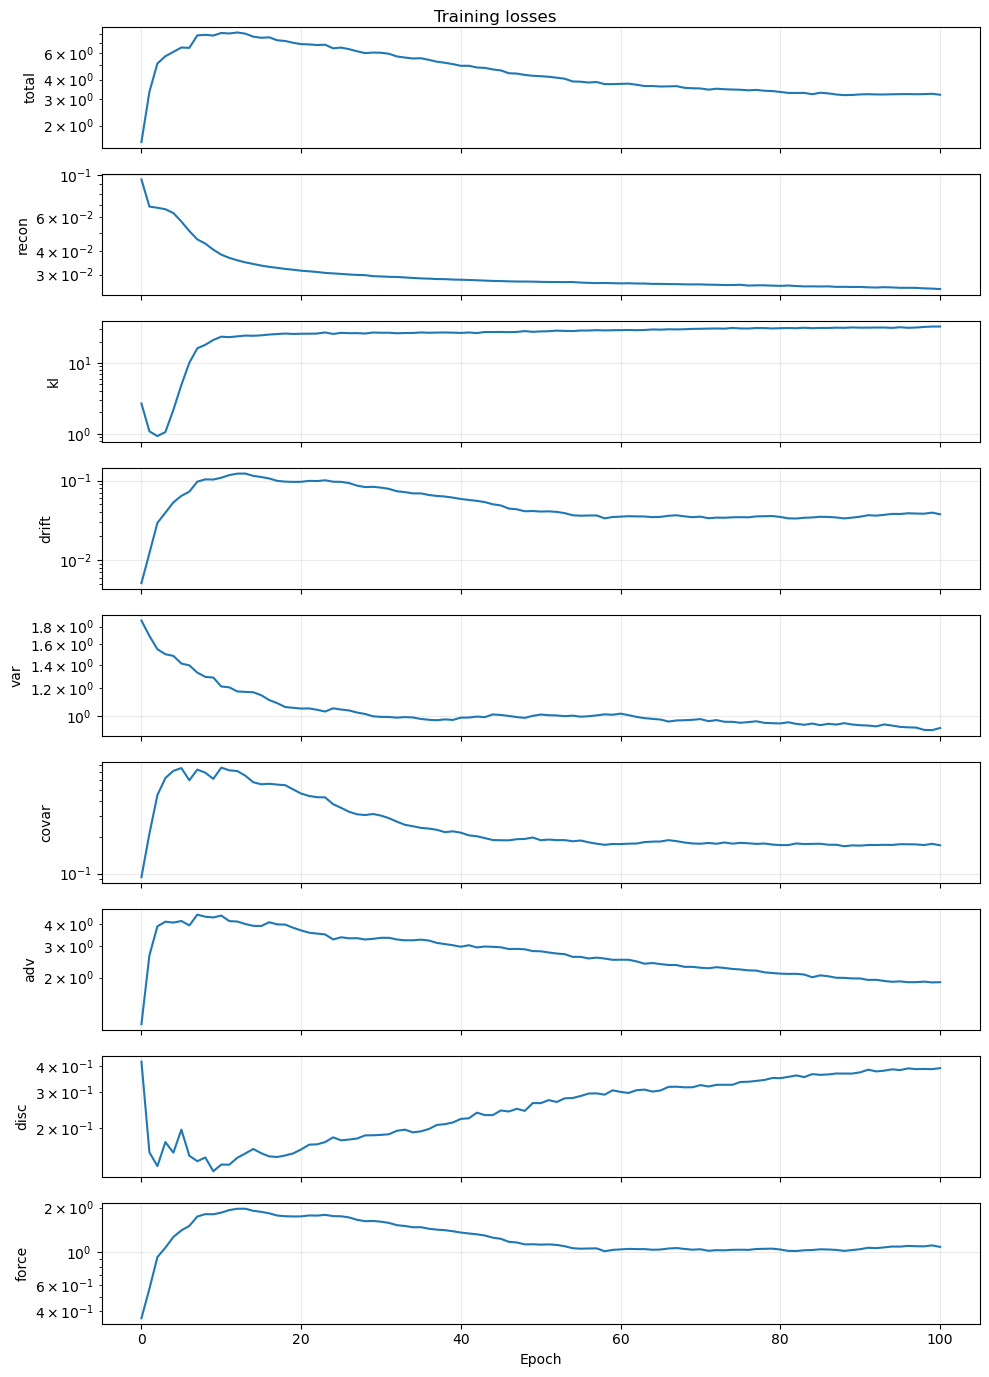

In [9]:
history = {
    "total": losses,
    "recon": recon_losses,
    "kl": kl_losses,
    "drift": drift_losses,
    "var": var_losses,
    "covar": covar_losses,
    "adv": adversarial_losses,
    "disc": discriminator_losses,
    "force": average_V,
}

fig, axes = plot_loss_history(
    history,
    keys=("total", "recon", "kl", "drift", "var", "covar", "adv", "disc", "force"),
)
plt.show()


In [ ]:
# One reusable post-training call: it collects real encoder means and
# conditional generated latents/images, then computes latent SWD/FID and class metrics.
post_eval = evaluate_latent_model(
    f_trained,
    test_loader,
    device=device,
    n_samples=2048,
    n_classes=NUM_CLASSES,
    class_to_label=CLASS_TO_DIGIT,
    include_mmd=False,
    include_fid=True,
)

samples = post_eval["samples"]
real_latents = samples["real_latents"]
generated_latents = samples["generated_latents"]
real_pixels = samples["real_images"]
generated_pixels = samples["generated_images"]
real_class_labels = samples["real_class_ids"]
generated_class_labels = samples["generated_class_ids"]
real_labels = samples["real_labels"]
generated_labels = samples["generated_labels"]
metrics = post_eval["metrics"]
latent_stats = post_eval["statistics"]

print("Latent-space metrics:")
for name, value in metrics.items():
    print(f"{name}: {value:.6f}")


In [ ]:
# This is the same compact metric interface in pixel space.
# Its FID is a pixel-space Fréchet distance; use evaluate_mnist_generation with a
# frozen evaluator when you specifically want learned MNIST-feature FID.
pixel_metrics = evaluate_generation(
    real_pixels,
    generated_pixels,
    generated_labels=generated_class_labels,
    n_classes=NUM_CLASSES,
    include_mmd=False,
)
print("Pixel-space metrics:")
for name, value in pixel_metrics.items():
    print(f"{name}: {value:.6f}")


In [ ]:
print("Latent statistics:")
for name, value in latent_stats.items():
    print(f"{name}: {value:.6f}")


In [ ]:
fig, axes = plot_conditional_mnist_results(
    f_trained,
    test_loader,
    device=device,
    samples=10,
    use_mean_for_reconstruction=True,
)
plt.show()


In [ ]:
projection_figures = plot_real_generated_projections(
    real_latents,
    generated_latents,
    real_labels=real_labels,
    generated_labels=generated_labels,
    methods=("pca", "umap"),
)
plt.show()
